In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import requests 
url="https://api.football-data.org/v4/competitions/SWE1/matches?season=2023"
headers = {"X-Auth-Token": "sample"
           }
data = {
    "team": [
        "Malmö FF", "Djurgårdens IF", "IFK Göteborg", "Hammarby IF",
        "IFK Norrköping", "BK Häcken", "AIK", "Kalmar FF",
        "Mjällby AIF", "IF Elfsborg", "Värnamo", "Halmstads BK",
        "Degerfors IF", "IK Sirius", "Landskrona BoIS", "GIF Sundsvall"
    ],
    "played": [30]*16,
    "wins": [20, 18, 15, 14, 13, 13, 12, 11, 10, 10, 8, 8, 7, 6, 5, 3],
    "draws": [6, 5, 7, 6, 6, 5, 6, 7, 8, 5, 7, 5, 6, 7, 5, 6],
    "losses": [4, 7, 8, 10, 11, 12, 12, 12, 12, 15, 15, 17, 17, 17, 20, 21],
    "goals_scored": [58, 52, 48, 45, 42, 50, 38, 36, 32, 35, 28, 25, 24, 22, 20, 15],
    "goals_conceded": [28, 32, 35, 38, 40, 42, 40, 45, 42, 50, 48, 55, 52, 55, 60, 65],
    "points": [66, 59, 52, 48, 45, 44, 42, 40, 38, 35, 31, 29, 27, 25, 20, 15]
}
df = pd.DataFrame(data)
df["goal_difference"]=df["goals_scored"]-df["goals_conceded"]
df["win_rate"]= (df["wins"]/df["played"] *100).round(1)
df["goals_per_game"]=df["goals_scored"]/df["played"].round(2)
print("✅ Veri hazır!")
print(f"📊 {len(df)} takım, {len(df.columns)} istatistik")
df

✅ Veri hazır!
📊 16 takım, 11 istatistik


,team,played,wins,draws,losses,goals_scored,goals_conceded,points,goal_difference,win_rate,goals_per_game
0,Malmö FF,30,20,6,4,58,28,66,30,66.7,1.933333
1,Djurgårdens IF,30,18,5,7,52,32,59,20,60.0,1.733333
2,IFK Göteborg,30,15,7,8,48,35,52,13,50.0,1.600000
3,Hammarby IF,30,14,6,10,45,38,48,7,46.7,1.500000
4,IFK Norrköping,30,13,6,11,42,40,45,2,43.3,1.400000
5,BK Häcken,30,13,5,12,50,42,44,8,43.3,1.666667
6,AIK,30,12,6,12,38,40,42,-2,40.0,1.266667
7,Kalmar FF,30,11,7,12,36,45,40,-9,36.7,1.200000
8,Mjällby AIF,30,10,8,12,32,42,38,-10,33.3,1.066667
9,IF Elfsborg,30,10,5,15,35,50,35,-15,33.3,1.166667


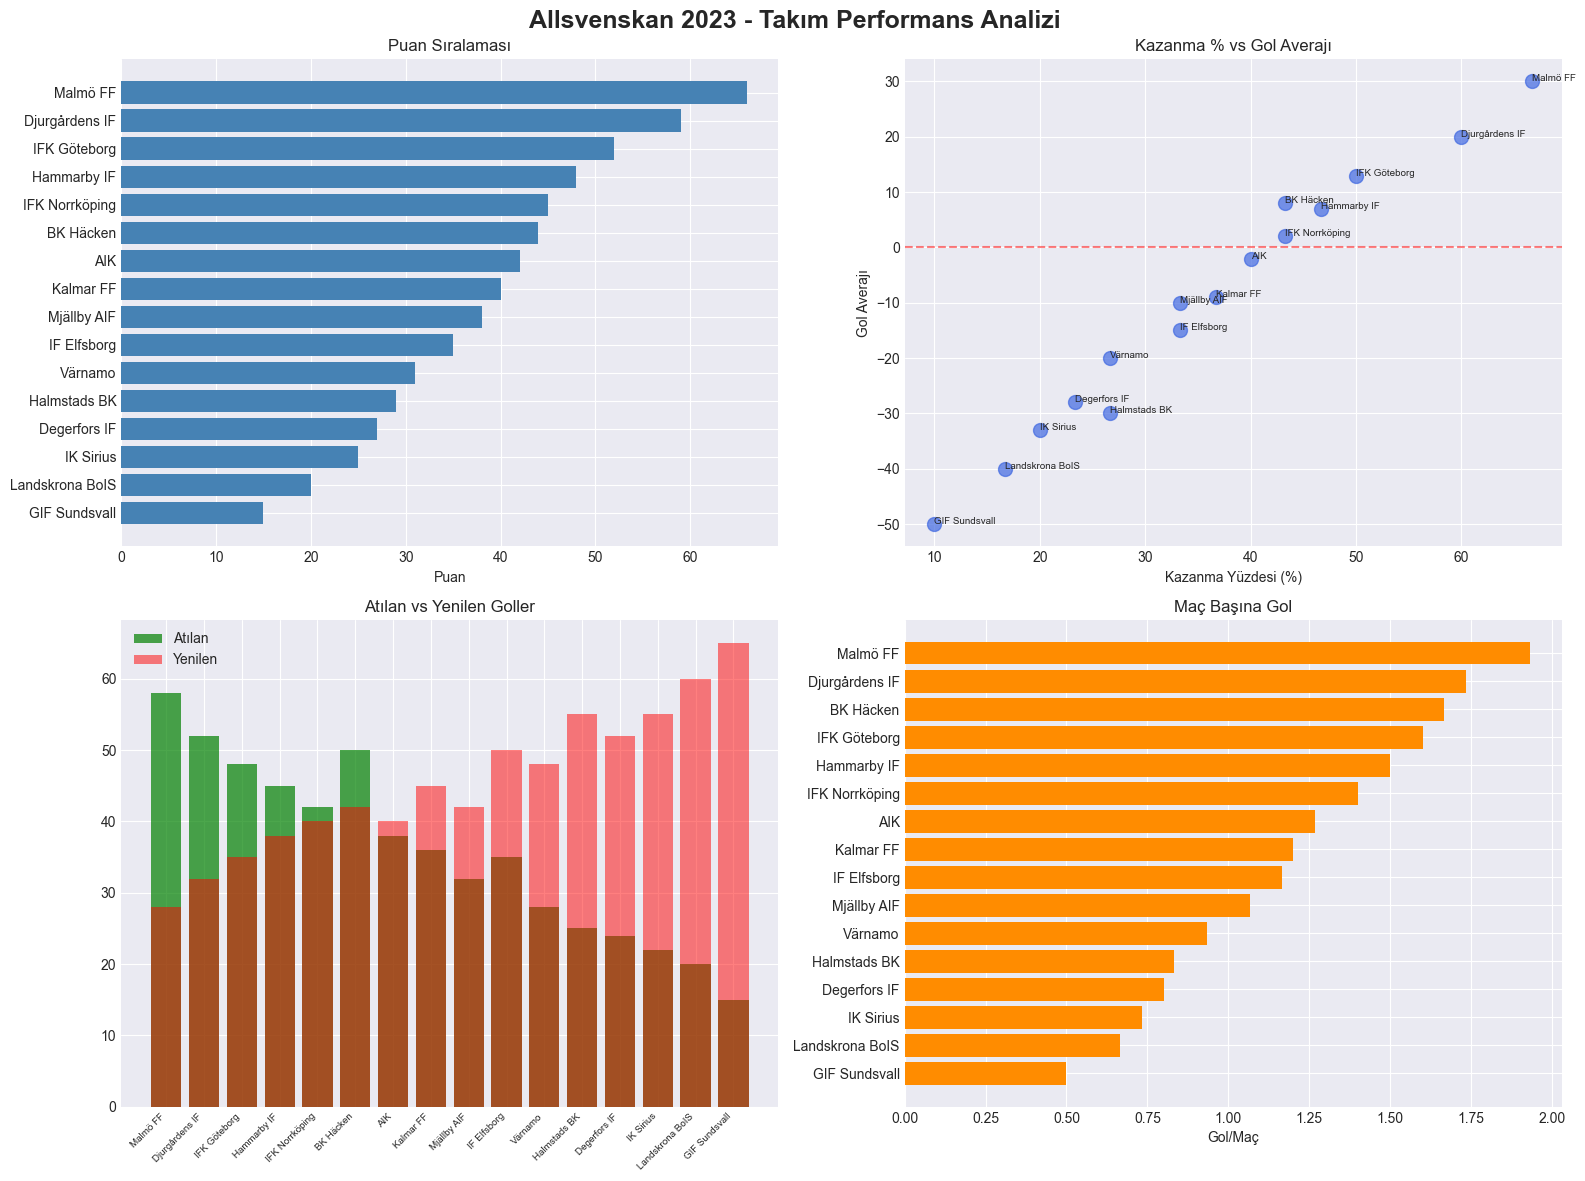

✅ Grafik kaydedildi!


In [3]:
plt.style.use("seaborn-v0_8-darkgrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Allsvenskan 2023 - Takım Performans Analizi", 
             fontsize=18, fontweight="bold")

# --- Grafik 1: Puan Sıralaması ---
# sort_values → puana göre sırala, ascending=False → büyükten küçüğe
df_sorted = df.sort_values("points", ascending=True)
axes[0,0].barh(df_sorted["team"], df_sorted["points"], color="steelblue")
axes[0,0].set_title("Puan Sıralaması")
axes[0,0].set_xlabel("Puan")

# --- Grafik 2: Kazanma Yüzdesi vs Gol Averajı ---
# scatter plot → iki değişken arasındaki ilişkiyi gösterir
# s=100 → nokta boyutu
axes[0,1].scatter(df["win_rate"], df["goal_difference"], 
                  s=100, color="royalblue", alpha=0.7)
# Her takımın adını noktanın yanına yaz
for i, row in df.iterrows():
    axes[0,1].annotate(row["team"], 
                       (row["win_rate"], row["goal_difference"]),
                       fontsize=7, ha="left")
axes[0,1].set_title("Kazanma % vs Gol Averajı")
axes[0,1].set_xlabel("Kazanma Yüzdesi (%)")
axes[0,1].set_ylabel("Gol Averajı")
axes[0,1].axhline(y=0, color="red", linestyle="--", alpha=0.5)
# axhline → yatay çizgi çiz (y=0 çizgisi, pozitif/negatif ayırır)

# --- Grafik 3: Atılan vs Yenilen Goller ---
x = range(len(df))
# bar → dikey bar grafiği
axes[1,0].bar(x, df["goals_scored"], label="Atılan", color="green", alpha=0.7)
axes[1,0].bar(x, df["goals_conceded"], label="Yenilen", color="red", alpha=0.5)
axes[1,0].set_xticks(x)
axes[1,0].set_xticklabels(df["team"], rotation=45, ha="right", fontsize=7)
axes[1,0].set_title("Atılan vs Yenilen Goller")
axes[1,0].legend()

# --- Grafik 4: Maç başına gol ---
df_goals = df.sort_values("goals_per_game", ascending=True)
axes[1,1].barh(df_goals["team"], df_goals["goals_per_game"], color="darkorange")
axes[1,1].set_title("Maç Başına Gol")
axes[1,1].set_xlabel("Gol/Maç")

plt.tight_layout()
plt.savefig("allsvenskan_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Grafik kaydedildi!")

In [5]:

print("📊 ALLSVENSKAN 2023 - ÖZET İSTATİSTİKLER")
print("="*50)

# idxmax() → en yüksek değerin index'ini verir
# loc[] → o index'teki satırı getirir
sampion = df.loc[df["points"].idxmax(), "team"]
print(f"🏆 Şampiyon: {sampion}")

en_cok_gol = df.loc[df["goals_scored"].idxmax(), "team"]
print(f"⚽ En çok gol atan: {en_cok_gol} ({df['goals_scored'].max()} gol)")

en_sağlam_savunma = df.loc[df["goals_conceded"].idxmin(), "team"]
print(f"🛡️ En sağlam savunma: {en_sağlam_savunma} ({df['goals_conceded'].min()} gol yedi)")

en_kotu = df.loc[df["points"].idxmin(), "team"]
print(f"😬 En kötü takım: {en_kotu} ({df['points'].min()} puan)")

print(f"\n📈 Ortalama maç başına gol: {df['goals_per_game'].mean().round(2)}")
print(f"💪 En yüksek kazanma oranı: %{df['win_rate'].max()}")
print(f"📉 En düşük kazanma oranı: %{df['win_rate'].min()}")

📊 ALLSVENSKAN 2023 - ÖZET İSTATİSTİKLER
🏆 Şampiyon: Malmö FF
⚽ En çok gol atan: Malmö FF (58 gol)
🛡️ En sağlam savunma: Malmö FF (28 gol yedi)
😬 En kötü takım: GIF Sundsvall (15 puan)

📈 Ortalama maç başına gol: 1.19
💪 En yüksek kazanma oranı: %66.7
📉 En düşük kazanma oranı: %10.0
